# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals
---
* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.

# Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [4]:
import joblib
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

In [3]:
test_path_csv = 'process_dataset/extracted_features/test_features.csv'
test_path_raw = 'process_dataset/test'
class_distribution_path = 'process_dataset/class_distribution_train.csv'

In [5]:
import utils

In [54]:
results = pd.read_csv("./model_results.csv")

results['test_acc'] = None
results['test_kappa'] = None
results['ev_time'] = None
results['cf_matrix_path']=None

# Dataset

In [11]:
df_test = pd.read_csv(test_path_csv)
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']
feature_cols = [c for c in df_test.columns if c not in cols_to_drop]
X_test = df_test[feature_cols]
y_test = df_test['Label']
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test.fillna(0))
X_test_seq, y_test_seq, _ = utils.build_sequences_per_subject(df_test, feature_cols, seq_len=30, step=5)

# Models test

In [75]:
def run_test_model(model_name, model, X_or_gen, y_true, results, mask, save_folder):

    # -----------------------------
    # MODELE TABULARE (sklearn)
    # -----------------------------
    if model_name in ["LGBM", "XGB", "RF", "LDA", "LR"]:
        y_proba = model.predict_proba(X_or_gen)
        y_pred = model.predict(X_or_gen)

    # -----------------------------
    # MODELE KERAS PE MATRICE
    # -----------------------------
    elif model_name in ["MLP", "LSTM", "ResNet"]:
        y_proba = model.predict(X_or_gen)
    
        # dacă modelul returnează vector 1D → îl convertim în probabilități one-hot
        if y_proba.ndim == 1:
            # convertim clasele în one-hot
            num_classes = len(np.unique(y_true))
            y_proba_fixed = np.zeros((len(y_proba), num_classes))
            y_proba_fixed[np.arange(len(y_proba)), y_proba.astype(int)] = 1
            y_proba = y_proba_fixed
    
        y_pred = y_proba.argmax(axis=1)

    # -----------------------------
    # MODELE CU GENERATOR
    # -----------------------------
    elif model_name in ["CNN", "SSN"]:
        all_y = []
        for i in range(len(X_or_gen)):
            _, yb = X_or_gen[i]
            all_y.append(np.argmax(yb, axis=1))
        y_true = np.concatenate(all_y)

        y_proba = model.predict(X_or_gen)
        y_pred = y_proba.argmax(axis=1)

    else:
        raise ValueError(f"Unknown model type: {model_name}")

    # -----------------------------
    # METRICS
    # -----------------------------
    acc, kappa, cf_path = utils.evaluate_model(
        y_true,
        y_pred,
        save_folder=save_folder,
        model_name=model_name
    )

    results.loc[mask, 'test_acc'] = acc
    results.loc[mask, 'test_kappa'] = kappa
    results.loc[mask, 'cf_matrix_path'] = cf_path

    return y_proba

## LightGBM

Confusion matrix saved at: ./results/confusion_matrix_LGBM.png
Accuracy: 0.7811
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



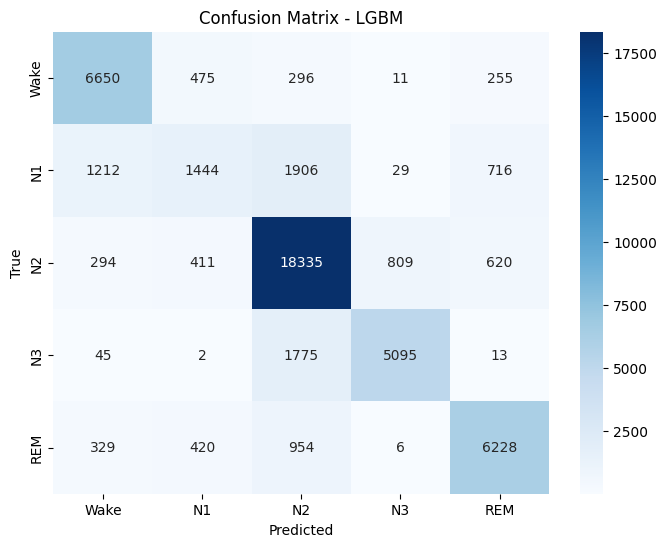

Cohen's Kappa: 0.6950


In [72]:
model_name = 'LGBM'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

y_proba_lgbm = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"

)

## XGBoost

Confusion matrix saved at: ./results/confusion_matrix_XGB.png
Accuracy: 0.7804
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.86      0.82      7687
          N1       0.52      0.28      0.36      5307
          N2       0.79      0.89      0.84     20469
          N3       0.85      0.73      0.79      6930
         REM       0.79      0.79      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



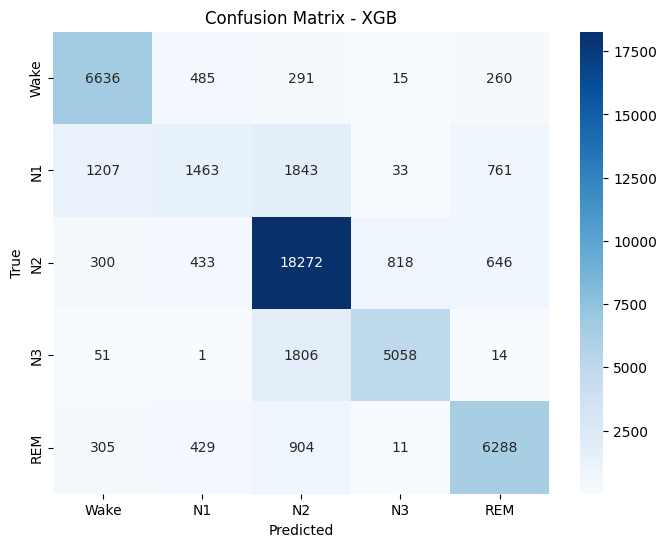

Cohen's Kappa: 0.6943


In [57]:
model_name = 'XGB'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"

)

## Random Forest

Confusion matrix saved at: ./results/confusion_matrix_RF.png
Accuracy: 0.7523
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.72      0.82      0.77      7687
          N1       0.49      0.24      0.32      5307
          N2       0.78      0.87      0.82     20469
          N3       0.85      0.70      0.77      6930
         REM       0.74      0.79      0.76      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.68      0.69     48330
weighted avg       0.74      0.75      0.74     48330



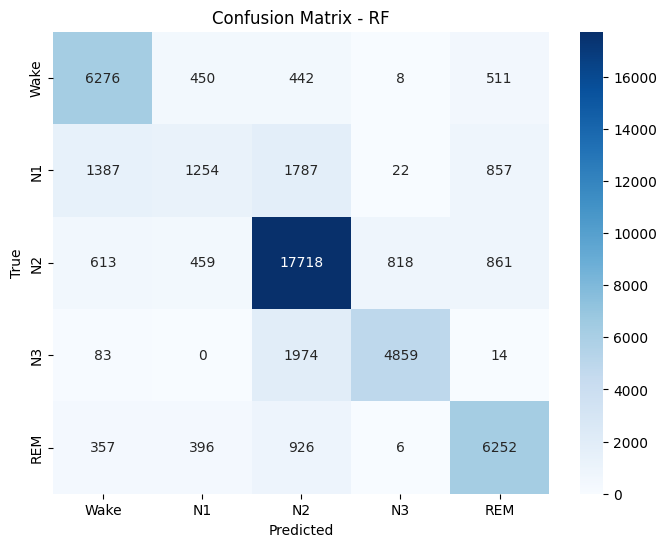

Cohen's Kappa: 0.6557


In [58]:
model_name = 'RF'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"

)

## LDA

Confusion matrix saved at: ./results/confusion_matrix_LDA.png
Accuracy: 0.7352
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.72      0.74      7687
          N1       0.41      0.31      0.35      5307
          N2       0.77      0.85      0.81     20469
          N3       0.79      0.69      0.74      6930
         REM       0.72      0.79      0.75      7937

    accuracy                           0.74     48330
   macro avg       0.69      0.67      0.68     48330
weighted avg       0.73      0.74      0.73     48330



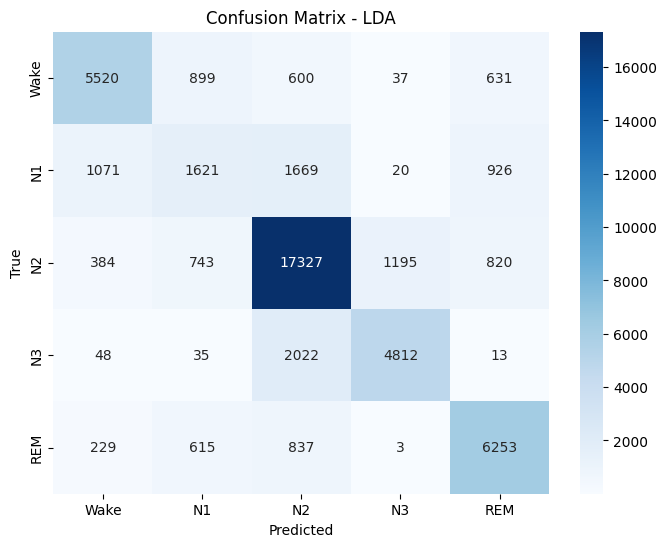

Cohen's Kappa: 0.6338


In [59]:
model_name = 'LDA'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## Logistic Regression

Confusion matrix saved at: ./results/confusion_matrix_LR.png
Accuracy: 0.7213
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.75      0.73      0.74      7687
          N1       0.35      0.44      0.39      5307
          N2       0.87      0.72      0.79     20469
          N3       0.72      0.84      0.77      6930
         REM       0.69      0.81      0.75      7937

    accuracy                           0.72     48330
   macro avg       0.68      0.71      0.69     48330
weighted avg       0.74      0.72      0.73     48330



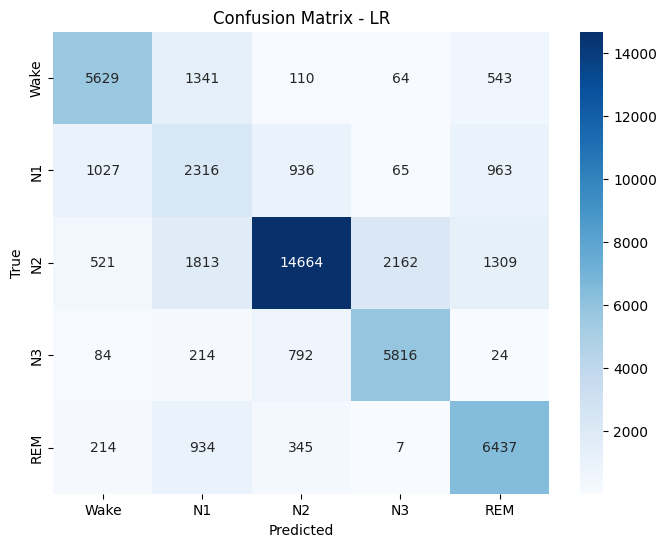

Cohen's Kappa: 0.6319


In [60]:
model_name = 'LR'
mask = (results['name'] == model_name)
model = joblib.load(results.loc[mask, 'path'].values[0])

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## MLP

Confusion matrix saved at: ./results/confusion_matrix_MLP.png
Accuracy: 0.7811
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



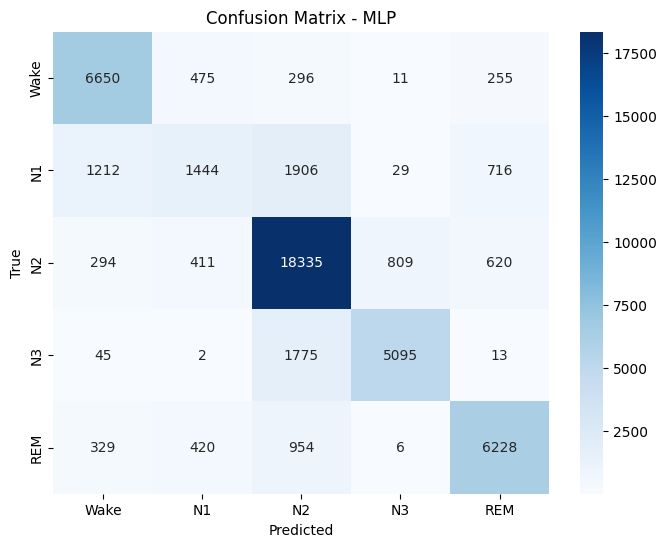

Cohen's Kappa: 0.6950


In [76]:
model_name = 'MLP'
mask = (results['name'] == model_name)
mlp_model = load_model(results.loc[mask,'path'].values[0])

y_proba_mlp = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test,
    y_true = y_test,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## LSTM

292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Confusion matrix saved at: ./results/confusion_matrix_LSTM.png
Accuracy: 0.7889
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.89      0.84      1395
          N1       0.53      0.26      0.35       977
          N2       0.80      0.86      0.83      3996
          N3       0.80      0.76      0.78      1387
         REM       0.82      0.86      0.84      1585

    accuracy                           0.79      9340
   macro avg       0.75      0.73      0.73      9340
weighted avg       0.77      0.79      0.78      9340



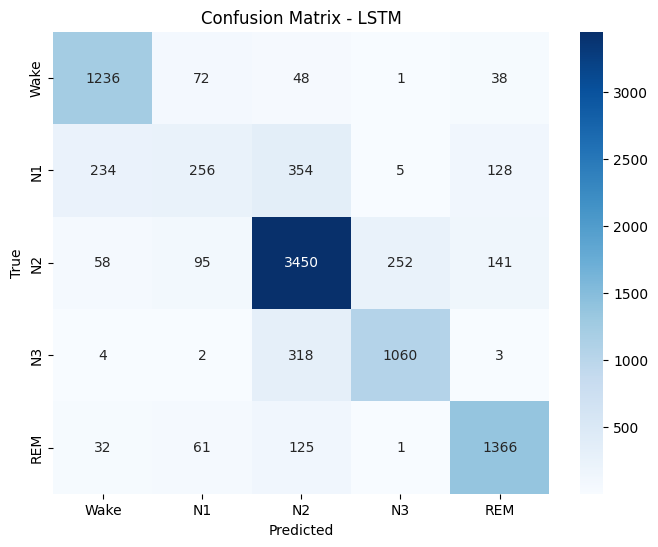

Cohen's Kappa: 0.7073


In [77]:
mask = (results['name'] == 'LSTM')
model_name = 'LSTM'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    custom_objects={
        "se_feature_attention": utils.se_feature_attention,
        "focal_loss": utils.categorical_focal_loss
    },
    compile=False
)

y_proba_lstm = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test_seq,
    y_true = y_test_seq,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## ResNet

292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion matrix saved at: ./results/confusion_matrix_ResNet.png
Accuracy: 0.7819
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.83      0.81      1395
          N1       0.46      0.34      0.39       977
          N2       0.80      0.87      0.83      3996
          N3       0.82      0.77      0.79      1387
         REM       0.84      0.81      0.82      1585

    accuracy                           0.78      9340
   macro avg       0.74      0.72      0.73      9340
weighted avg       0.77      0.78      0.78      9340



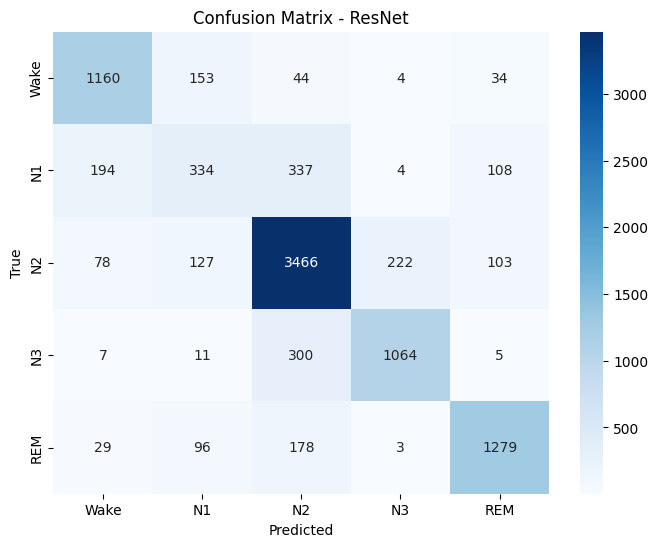

Cohen's Kappa: 0.6979


In [78]:
model_name = 'ResNet'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0],
    compile=False
)

y_proba_resnet = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = X_test_seq,
    y_true = y_test_seq,
    results= results,
    mask = mask,
    save_folder = "./results"
)

## 1D-CNN

57/57 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step
Confusion matrix saved at: ./results/confusion_matrix_CNN.png
Accuracy: 0.7704
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.94      0.82      7621
          N1       0.51      0.19      0.27      5260
          N2       0.80      0.87      0.83     20468
          N3       0.79      0.77      0.78      6930
         REM       0.77      0.75      0.76      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.70      0.69     48216
weighted avg       0.75      0.77      0.75     48216



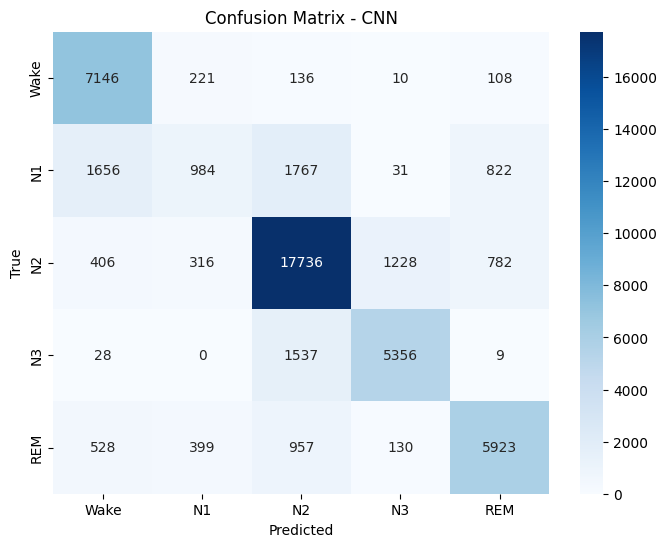

Cohen's Kappa: 0.6822


In [64]:
test_gen = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

model_name = 'CNN'
mask = (results['name'] == model_name)
model = load_model(
    results.loc[mask,'path'].values[0], 
    compile=False
)

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = test_gen,
    y_true = None,
    results= results,
    mask = mask,
    save_folder = "./results"
)

# start_time = time.time()
# # Predict probabilities
# y_proba_cnn = cnn_model.predict(test_gen)

# # Predict final class
# y_pred_cnn = y_proba_cnn.argmax(axis=1)
# end_time = time.time()


# # Extract true labels from generator
# y_true_cnn = []
# for i in range(len(test_gen)):
#     _, y_batch = test_gen[i]
#     y_true_cnn.extend(np.argmax(y_batch, axis=1))
# y_true_cnn = np.array(y_true_cnn)

# # Save metrics
# results.loc[mask,'ev_time'] = end_time - start_time
# results.loc[mask,'test_acc'], \
# results.loc[mask,'test_kappa'], \
# results.loc[mask,'cf_matrix_path'] = utils.evaluate_model(
#     y_true_cnn,
#     y_pred_cnn,
#     save_folder='results',
#     model_name='CNN'
# )

## SeqSleepNet

57/57 ━━━━━━━━━━━━━━━━━━━━ 804s 13s/step
Confusion matrix saved at: ./results/confusion_matrix_SSN.png
Accuracy: 0.7655
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.79      0.87      0.83      7621
          N1       0.49      0.28      0.35      5260
          N2       0.80      0.85      0.82     20468
          N3       0.79      0.78      0.78      6930
         REM       0.73      0.77      0.75      7937

    accuracy                           0.77     48216
   macro avg       0.72      0.71      0.71     48216
weighted avg       0.75      0.77      0.75     48216



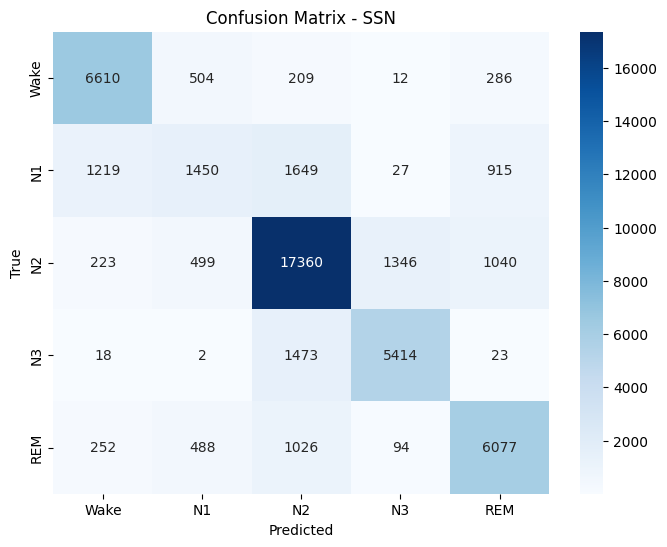

Cohen's Kappa: 0.6770


In [67]:
import utils
test_gen_seq = utils.SleepDataGenerator(
    test_path_raw,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0] 
)

model_name = 'SSN'
mask = (results['name'] == model_name)

custom_objects = {
    "Attention": utils.Attention,
    "se_feature_attention": utils.se_feature_attention,
    "categorical_focal_loss": utils.categorical_focal_loss(),
    "loss": utils.categorical_focal_loss(),
}

model = load_model(
    results.loc[mask, 'path'].values[0],
    custom_objects=custom_objects,
    compile=False
)

_ = run_test_model(
    model_name = model_name,
    model = model,
    X_or_gen = test_gen_seq,
    y_true = None,
    results= results,
    mask = mask,
    save_folder = "./results"
)

# Ensemble

In [80]:
import numpy as np

def ensemble_weight_search(y_true, y_proba_A, y_proba_B):
    best_w = None
    best_kappa = -999
    best_acc = -999

    for w in np.linspace(0, 1, 21):  # 0.00, 0.05, ..., 1.00
        y_proba_ens = w * y_proba_A + (1 - w) * y_proba_B
        y_pred_ens = y_proba_ens.argmax(axis=1)

        acc, kappa = utils.evaluate_model(
            y_true,
            y_pred_ens,
            disable_view=False
        )
        
        if kappa > best_kappa:
            best_kappa = kappa
            best_acc = acc
            best_w = w

    return best_w, best_acc, best_kappa

In [81]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test,
    y_proba_lgbm,
    y_proba_mlp
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.0
Best acc: 0.7811297330850403
Best kappa: 0.694964806891643


Confusion matrix saved at: results/confusion_matrix_LGBM_MLP.png
Accuracy: 0.7811
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.87      0.82      7687
          N1       0.52      0.27      0.36      5307
          N2       0.79      0.90      0.84     20469
          N3       0.86      0.74      0.79      6930
         REM       0.80      0.78      0.79      7937

    accuracy                           0.78     48330
   macro avg       0.75      0.71      0.72     48330
weighted avg       0.77      0.78      0.77     48330



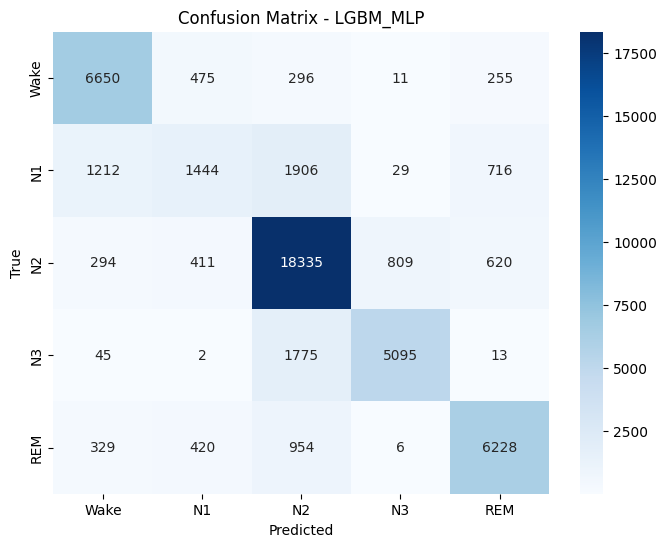

Cohen's Kappa: 0.6950


NameError: name 'test_acc' is not defined

In [82]:
start_time = time.time()
y_proba_ens = 0.35 * y_proba_lgbm + (1 - 0.35) * y_proba_mlp
y_pred_ens = y_proba_ens.argmax(axis=1)
end_time = time.time()

acc_ens, kappa_ens, path = utils.evaluate_model(
    y_test, y_pred_ens,
    save_folder='results',
    model_name='LGBM_MLP'
)

# results.loc[len(results)] = {
#     "name": "LGBM_MLP",
#     "type": "Ensemble",
#     "test_acc": acc_ens,
#     "test_kappa": kappa_ens,
#     "ev_time": end_time - start_time,
#     "cf_matrix_path": path,
#     "path": None
# }

results.loc[results['name'] == 'LGBM_MLP',test_acc] = acc_ens
results.loc[results['name'] == 'LGBM_MLP',test_kappa] = kappa_ens
results.loc[results['name'] == 'LGBM_MLP',cf_matrix_path] = path

## LSTM + ResNet

In [83]:
best_w, best_acc, best_kappa = ensemble_weight_search(
    y_test_seq,
    y_proba_lstm,
    y_proba_resnet
)

print("Best weight:", best_w)
print("Best acc:", best_acc)
print("Best kappa:", best_kappa)

Best weight: 0.65
Best acc: 0.797644539614561
Best kappa: 0.7193767444068297


Confusion matrix saved at: results/confusion_matrix_LSTM_ResNet.png
Accuracy: 0.7976
--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.81      0.87      0.84      1395
          N1       0.54      0.33      0.41       977
          N2       0.81      0.87      0.84      3996
          N3       0.82      0.78      0.80      1387
         REM       0.83      0.85      0.84      1585

    accuracy                           0.80      9340
   macro avg       0.76      0.74      0.74      9340
weighted avg       0.79      0.80      0.79      9340



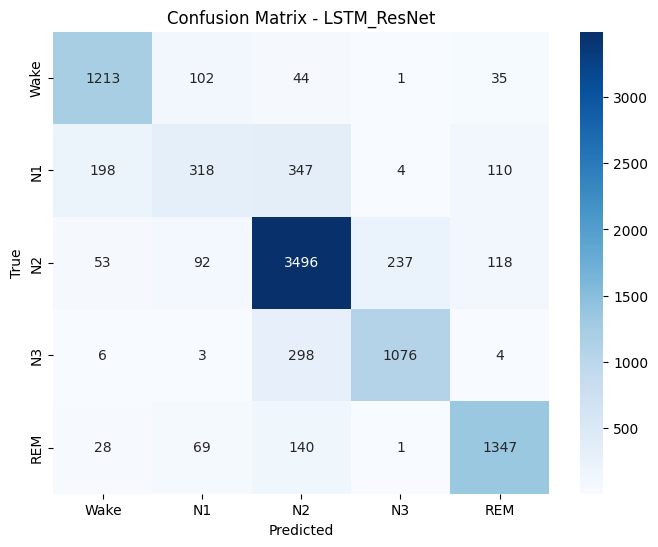

Cohen's Kappa: 0.7194


In [85]:
start_time = time.time()
y_proba_ens = 0.65 * y_proba_lstm + (1 - 0.65) * y_proba_resnet
y_pred_ens_seq = y_proba_ens.argmax(axis=1)
end_time = time.time()

acc_ens, kappa_ens, path = utils.evaluate_model(
    y_test_seq, y_pred_ens_seq,
    save_folder='results',
    model_name='LSTM_ResNet'
)

results.loc[len(results)] = {
    "name": "LSTM_ResNet",
    "type": "Ensemble",
    "test_acc": acc_ens,
    "test_kappa": kappa_ens,
    "ev_time": end_time - start_time,
    "cf_matrix_path": path,
    "path": None
}

In [89]:
results.to_csv("./model_results.csv", index=False)